In [1]:
import pandas as pd
from pathlib import Path

MODELS_DIR = Path.cwd().parent / "models"
csvs = list(MODELS_DIR.glob("*_metrics.csv"))
dfs = [pd.read_csv(p).assign(file=p.name) for p in csvs]
results = pd.concat(dfs, ignore_index=True)

# Rank by lowest RMSE
display(results.sort_values("RMSE"))

,Model,MAE,RMSE,R2,file
2,RandomForestRegressor,2530.361637,4621.202443,0.862443,random_forest_regressor_metrics.csv
3,xgboost_regressor,2533.387027,4668.616147,0.859606,xgboost_regressor_metrics.csv
0,LinearRegression,4181.194474,5796.284659,0.783593,linear_regression_metrics.csv
4,DecisionTreeRegressor,2939.727836,6152.849170,0.756149,decision_tree_regressor_metrics.csv
1,KNN Regressor,7153.333235,10397.644366,0.303627,knn_regressor_metrics.csv


,Model,MAE,RMSE,R2,file
0,RandomForestRegressor,2530.361637,4621.202443,0.862443,random_forest_regressor_metrics.csv
1,xgboost_regressor,2533.387027,4668.616147,0.859606,xgboost_regressor_metrics.csv
2,LinearRegression,4181.194474,5796.284659,0.783593,linear_regression_metrics.csv
3,DecisionTreeRegressor,2939.727836,6152.849170,0.756149,decision_tree_regressor_metrics.csv
4,KNN Regressor,7153.333235,10397.644366,0.303627,knn_regressor_metrics.csv



Best model: RandomForestRegressor  |  RMSE = 4621.20
Improvement over Linear Regression: 20.3%


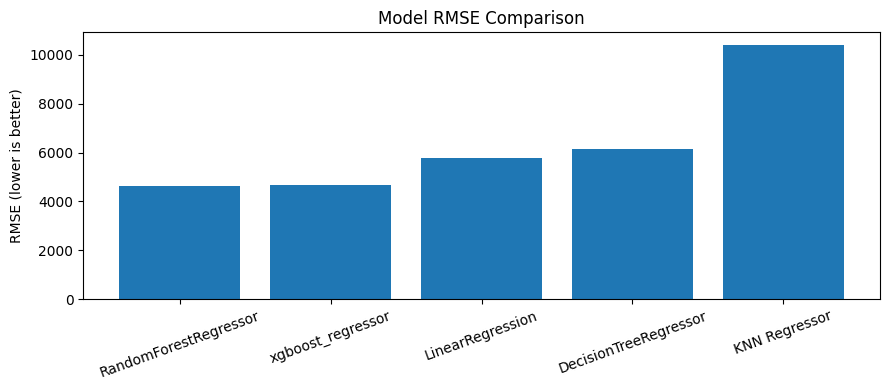

In [2]:
import matplotlib.pyplot as plt
import numpy as np

ranked = results.sort_values("RMSE").reset_index(drop=True)
best = ranked.iloc[0]
baseline = ranked[ranked["Model"].str.contains("LinearRegression", case=False, na=False)]
if not baseline.empty:
    baseline_rmse = baseline.iloc[0]["RMSE"]
    improvement = (baseline_rmse - best["RMSE"]) / baseline_rmse * 100
else:
    baseline_rmse = np.nan
    improvement = np.nan

display(ranked)

print(f"\nBest model: {best['Model']}  |  RMSE = {best['RMSE']:.2f}")
if not np.isnan(improvement):
    print(f"Improvement over Linear Regression: {improvement:.1f}%")

# Plot RMSE
plt.figure(figsize=(9,4))
plt.bar(ranked["Model"], ranked["RMSE"])
plt.ylabel("RMSE (lower is better)")
plt.title("Model RMSE Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [3]:
summary_path = (MODELS_DIR / "model_comparison_summary.csv")
ranked.to_csv(summary_path, index=False)
summary_path

PosixPath('/Users/abdulmohsenalmunayes/Projects/insurance-ml-project/models/model_comparison_summary.csv')

In [4]:
winner_file = ranked.iloc[0]["file"]      # e.g., random_forest_regressor_metrics.csv
winner_model = ranked.iloc[0]["Model"]
winner_joblib = winner_file.replace("_metrics.csv", ".joblib")
print("Winner:", winner_model, "->", winner_joblib)

# Write a tiny pointer file the app can read
pointer_path = MODELS_DIR / "best_model.txt"
with open(pointer_path, "w") as f:
    f.write(winner_joblib)
pointer_path

Winner: RandomForestRegressor -> random_forest_regressor.joblib


PosixPath('/Users/abdulmohsenalmunayes/Projects/insurance-ml-project/models/best_model.txt')